<a href="https://colab.research.google.com/github/takiwaki/Blastwave/blob/main/SphericalGRchi_gemi_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BSSN equations in spherical coordinates without regularization: Vacuum and nonvacuum spherically symmetric spacetimes

Montero, Pedro J. ; Cordero-Carrión, Isabel

$$d s^2 = -\alpha d t^2+\frac{1}{\chi}\left[ a(r,t) d r^2 + r^2 b(r,t) d\Omega^2\right]$$

$$ \partial_t \chi = \frac{1}{6}\sigma D_m \beta^m -\frac{1}{6}\alpha K $$
$$ \partial_t K = -\nabla^2 \alpha +\alpha\left(A_{ij}A^{ij}+\frac{1}{3}K^2\right)$$
$$ \partial_t a = -2\alpha a{A^{r}}_r $$
$$ \partial_t b = -2\alpha b{A^{\theta}}_\theta $$
$$ \partial_t \alpha= -\alpha^2 K $$
$\beta = 0$ for pure gauge
$${A^r}_r = \frac{2}{3}r^2 A_\lambda$$
$${A^\theta}_\theta = -\frac{1}{3}r^2 A_\lambda$$
$$ \partial_t A_\lambda = \beta^r \partial_r A_\lambda +\cdots$$
In the PIRK method,
$$\partial_t u = L_1(u,v)$$
$$\partial_t v = L_2(u) + L_3(u,v)$$

$$ u^* = u^n + \Delta t L_1(u^n,v^n)$$
$$ v^* = v^n + \Delta t \left[ +\frac{1}{2}L_2(u^n) +\frac{1}{2}L_2(u^*) +L_3(u^n,v^n) \right]$$

$$ u^{n+1} = \frac{1}{2}\left[u^n + u^* +\Delta t L_1(u^*,v^*)\right]$$
$$ v^{n+1} = v^n + \frac{\Delta t}{2} \left[ +L_2(u^n) + L_2(u^{n+1}) +L_3(u^n,v^n)  +L_3(u^*,v^*) \right]$$
Here
$u = \chi({\rm or}X),a,b,\alpha, \beta^r$ and $v=K, A_a, \hat{\Delta}^r, B^r$


# 備忘録：BSSN方程式におけるRicciテンソルと $\Lambda^r$ の循環参照問題の解決策（PIRK2法）

Baumgarte et al. (2013) の Appendix B に基づく、**「暫定更新（Provisional update）と上書き」** を用いた PIRK2 (Partially Implicit Runge-Kutta 2nd order) 法のアルゴリズムの整理です。

## 1. 前提：変数とオペレータの定義

* **陽的変数 $u$**: $\alpha, \beta^r, X, a, b$
* **半暗的変数 $v$**: $K, A_a, \Lambda^r, B^r$ （剛的な微分項を持つ変数）

方程式の右辺（ソース項）を以下の3つのオペレータに分離します。
* **$L_1(u, v)$**: $u$ の時間微分（陽的ソース項）。
* **$L_2(u, v)$**: $v$ の時間微分のうち、**剛的（Stiff）な項**。
  * *【重要】*: $A_a$ の更新式には Ricci テンソル $R_{ij}$ が含まれますが、これを計算するには**最新の $\Lambda^r$（すなわち $v$ の成分）**が必要です。
* **$L_3(u, v)$**: $v$ の時間微分のうち、移流項などの**非剛的な項**。

---

## 2. PIRK2 タイムステップのアルゴリズム

ステップ $n$ から $n+1$ へ時間を $\Delta t$ 進める手順です。循環参照を断ち切るために「暫定的な陽的更新」を挟むのが特徴です。

### 【Step 0】 現在のステップのオペレータ評価
まず、現在の時間レベル $t^n$ の変数を用いて各オペレータを評価します。
$$L_1^n = L_1(u^n, v^n)$$
$$L_2^n = L_2(u^n, v^n)$$
$$L_3^n = L_3(u^n, v^n)$$

---

### 【Step 1】 Stage 1 （中間予測ステップ）

**1. 陽的変数 $u$ の更新**
$$u^{(1)} = u^n + \Delta t L_1^n$$

**2. 半暗的変数 $v$ の「暫定」陽的更新 (Provisional Update)**
まだ新しい $L_2$ が計算できないため、とりあえず純粋な陽的オイラー法で $v$ を進めます。
$$v_{prov}^{(1)} = v^n + \Delta t \left( L_2^n + L_3^n \right)$$

**3. 新しい状態での $L_2$ の評価**
暫定的に求めた $v_{prov}^{(1)}$（これには最新の $\Lambda^r$ の近似値が含まれます）を使って、Ricci テンソルを含む剛的な項を評価します。
$$L_2^{(1)} = L_2(u^{(1)}, v_{prov}^{(1)})$$

**4. 半暗的変数 $v$ の正式な更新（上書き）**
PIRK2の本来の公式に従い、$L_2$ を時間平均（台形則的）にして $v$ を更新し直します。
$$v^{(1)} = v^n + \Delta t \left( \frac{1}{2} L_2^n + \frac{1}{2} L_2^{(1)} + L_3^n \right)$$

---

### 【Step 2】 Stage 2 （最終修正ステップ）

**5. Stage 1 の結果を用いたオペレータ評価**
$$L_1^{(1)} = L_1(u^{(1)}, v^{(1)})$$
$$L_3^{(1)} = L_3(u^{(1)}, v^{(1)})$$

**6. 陽的変数 $u$ の最終更新**
$$u^{n+1} = \frac{1}{2} \left( u^n + u^{(1)} + \Delta t L_1^{(1)} \right)$$

**7. 半暗的変数 $v$ の「暫定」陽的更新 (Provisional Update)**
Stage 1と同様に、最新の $L_2^{n+1}$ を計算するために、陽的なRK2ステップの公式を使って $v$ を暫定的に進めます。
$$v_{prov}^{n+1} = v^n + \frac{\Delta t}{2} \left( L_2^n + L_2^{(1)} + L_3^n + L_3^{(1)} \right)$$

**8. 最新の状態での $L_2$ の評価**
暫定値 $v_{prov}^{n+1}$ を使って Ricci テンソルを含む $L_2$ を評価します。
$$L_2^{n+1} = L_2(u^{n+1}, v_{prov}^{n+1})$$

**9. 半暗的変数 $v$ の最終更新（上書き）**
最後に、PIRK2の正式な公式で $v^{n+1}$ を確定させます。
$$v^{n+1} = v^n + \frac{\Delta t}{2} \left( L_2^n + L_2^{n+1} + L_3^n + L_3^{(1)} \right)$$

---

## 3. この手法の核心（まとめ）

1. **「Ricciテンソル（$L_2$）を計算したいけど、最新の $\Lambda^r$ がまだ無い！」**
2. $\Rightarrow$ **「なら、今手元にある $L_2$ と $L_3$ を使って、陽的（Explicit）に一時的な $\Lambda^r_{prov}$ を作ってしまおう。」**
3. $\Rightarrow$ **「その一時的な $\Lambda^r_{prov}$ で Ricci テンソルを計算して新しい $L_2$ をゲットする。」**
4. $\Rightarrow$ **「新しい $L_2$ が手に入ったら、本来の半暗的（Semi-implicit）な公式を使って $v$ を正しく計算し直す（上書きする）。」**

In [1]:
import numpy as np

class BSSNSolver:
    # 変数インデックスを Baumgarte 2013 風に変更
    uidchi = 0
    uidgrr = 1
    uidgtt = 2
    uidalpha = 3
    uidbeta_r= 4

    vidK = 0
    vidArr = 1
    vidLambda_r = 2
    vidBr = 3

    def __init__(self, Nr, dr, alpha0=0.01, r0=5.0, eps_ko=0.05):
        self.Nr = Nr
        self.dr = dr
        self.nghost = 3  # 6階微分(7点ステンシル)のため3に設定
        self.eps_ko = eps_ko  # KO散逸パラメータ (0.01 ~ 0.1 が標準的)

        self.r = np.linspace(dr/2 - self.nghost*dr, (Nr-0.5)*dr + self.nghost*dr, Nr + 2*self.nghost)
        self.u = np.zeros((5, len(self.r)))
        self.v = np.zeros((4, len(self.r)))

        self.init_pure_gauge(alpha0, r0)
        self.apply_boundaries(self.u, self.v)

    def init_pure_gauge(self, alpha0, r0):
        self.u[self.uidchi, :] = 1.0
        self.u[self.uidgrr, :] = 1.0
        self.u[self.uidgtt, :] = 1.0
        r = self.r
        term = (alpha0 * r**2) / (1 + r**2)
        gauss = np.exp(-(r - r0)**2) + np.exp(-(r + r0)**2)
        self.u[self.uidalpha, :] = 1.0 + term * gauss
        self.u[self.uidbeta_r, :] = 0.0

    def apply_boundaries(self, u, v):
        ng = self.nghost
        # 原点パリティ (偶関数)
        for i in [self.uidchi, self.uidgrr, self.uidgtt, self.uidalpha]:
            u[i, 0:ng] = u[i, ng:2*ng][::-1]

        # 原点パリティ (奇関数)
        u[self.uidbeta_r, 0:ng] = -u[self.uidbeta_r, ng:2*ng][::-1]

        # 原点パリティ (偶関数)
        for i in [self.vidK, self.vidArr]:
            v[i, 0:ng] = v[i, ng:2*ng][::-1]

        # 原点パリティ (奇関数)
        for i in [self.vidLambda_r, self.vidBr]:
            v[i, 0:ng] = -v[i, ng:2*ng][::-1]

        # 外側境界
        for i in range(u.shape[0]):
            u[i, -ng:] = u[i, -ng-1]
        for i in range(v.shape[0]):
            v[i, -ng:] = v[i, -ng-1]

    def der1(self, f):
        df = np.zeros_like(f)
        df[3:-3] = (-f[5:-1] + 8*f[4:-2] - 8*f[2:-4] + f[1:-5]) / (12*self.dr)
        return df

    def der2(self, f):
        d2f = np.zeros_like(f)
        d2f[3:-3] = (-f[5:-1] + 16*f[4:-2] - 30*f[3:-3] + 16*f[2:-4] - f[1:-5]) / (12*self.dr**2)
        return d2f

    def get_ko_rate(self, f):
        """KO散逸を時間微分(Rate)として計算する"""
        ko = np.zeros_like(f)
        ko[:, 3:-3] = (self.eps_ko / (64.0 * self.dr)) * (
            f[:, 6:] - 6*f[:, 5:-1] + 15*f[:, 4:-2] - 20*f[:, 3:-3] + 15*f[:, 2:-4] - 6*f[:, 1:-5] + f[:, :-6]
        )
        return ko

    def get_ricci(self, chi, grr, gtt, Lambda_r):
        r = self.r
        d_grr = self.der1(grr); d2_grr = self.der2(grr)
        d_gtt = self.der1(gtt); d2_gtt = self.der2(gtt)
        d_chi = self.der1(chi); d2_chi = self.der2(chi)
        d_Lambda = self.der1(Lambda_r)

        # phi に相当する対数微分
        d_phi = -0.5 * d_chi / chi
        d2_phi = -0.5 * d2_chi / chi + 0.5 * (d_chi / chi)**2
        factor = (chi**2) / grr

        term_a = d2_grr / (2*grr) - grr * d_Lambda - 0.75 * (d_grr/grr)**2 + 0.5 * (d_gtt/gtt)**2
        term_b = -0.5 * Lambda_r * d_grr + d_grr / (r*gtt)
        term_c = (2 / r**2) * (1 - grr/gtt) * (1 + r * d_gtt / gtt)
        term_d = 4 * d2_phi - 2 * d_phi * (d_grr/grr - d_gtt/gtt - 2/r)
        R_rr = -factor * (term_a + term_b + term_c + term_d)

        term_R1 = d2_grr / (2*grr) + d2_gtt / gtt - grr * d_Lambda - (d_grr/grr)**2 + 0.5 * (d_gtt/gtt)**2
        term_R2 = (2 / (r*gtt)) * (3 - grr/gtt) * d_gtt + (4 / r**2) * (1 - grr/gtt)
        term_R3 = 8 * (d2_phi + d_phi**2) - 8 * d_phi * (d_grr/(2*grr) - d_gtt/gtt - 2/r)
        R = -factor * (term_R1 + term_R2 + term_R3)
        return R_rr, R

    def get_L1(self, u, v):
        chi, grr, gtt, alpha, beta_r = u
        K, Arr, Lambda_r, Br = v

        L1 = self.get_ko_rate(u)

        d_beta_r = self.der1(beta_r)
        div_beta = d_beta_r + beta_r * (self.der1(grr*gtt**2)/(2*grr*gtt**2) + 2/self.r)

        L1[self.uidchi] += beta_r * self.der1(chi) - (1/3) * chi * (alpha * K - div_beta)
        L1[self.uidgrr] += beta_r * self.der1(grr) + 2*grr*d_beta_r - (2/3)*grr*div_beta - 2*alpha*grr*Arr
        Att = -0.5 * Arr
        L1[self.uidgtt] += beta_r * self.der1(gtt) + 2*gtt*beta_r/self.r - (2/3)*gtt*div_beta - 2*alpha*gtt*Att
        L1[self.uidalpha] += - (alpha**2) * K
        L1[self.uidbeta_r] = 0.0  # Zero shift
        return L1

    def get_L2(self, u, v):
        chi, grr, gtt, alpha, beta_r = u
        K, Arr, Lambda_r, Br = v
        r = self.r
        L2 = np.zeros((4, len(r)))

        d_alpha = self.der1(alpha); d2_alpha = self.der2(alpha)
        d_grr = self.der1(grr); d_gtt = self.der1(gtt); d_chi = self.der1(chi)

        term_lap = (d2_alpha - d_alpha * (d_grr/(2*grr) - d_gtt/gtt - 2.0*d_chi/chi - 2/r))
        L2[self.vidK] = - (chi**2 / grr) * term_lap

        R_rr, R = self.get_ricci(chi, grr, gtt, Lambda_r)

        lap_alpha = (chi**2 / grr) * term_lap
        d_phi = -0.5 * d_chi / chi
        nabla_rr_alpha = (chi**2 / grr) * (d2_alpha - d_alpha * (d_grr/(2*grr) + 2*d_phi))

        L2[self.vidArr] = - (nabla_rr_alpha - (1/3)*lap_alpha) + alpha * (R_rr - (1/3)*R)
        L2[self.vidLambda_r] = (1/grr) * self.der2(beta_r) + (2/gtt) * self.der1(beta_r/r)
        return L2

    def get_L3(self, u, v):
        chi, grr, gtt, alpha, beta_r = u
        K, Arr, Lambda_r, Br = v
        r = self.r

        L3 = self.get_ko_rate(v)

        d_beta_r = self.der1(beta_r); d_Lambda = self.der1(Lambda_r)
        d_alpha = self.der1(alpha); d_Arr = self.der1(Arr)
        d_K = self.der1(K); d_gtt = self.der1(gtt)
        d_chi = self.der1(chi); d_phi = -0.5 * d_chi / chi

        Att = -0.5 * Arr
        L3[self.vidK] += beta_r * d_K + alpha * (Arr**2 + 2*Att**2 + (1.0/3.0)*K**2)
        L3[self.vidArr] += beta_r * d_Arr + alpha * K * Arr

        xi = 2.0
        term1_L3 = beta_r * d_Lambda - Lambda_r * d_beta_r
        term2_L3 = - (2.0 / grr) * (Arr * d_alpha + alpha * d_Arr)
        term3_L3 = 2.0 * alpha * (Arr * Lambda_r - (2.0 / (r * gtt)) * (Arr - Att))
        term4_L3 = (alpha * xi / grr) * (d_Arr - (2.0/3.0)*d_K + 6.0 * Arr * d_phi + (Arr - Att) * (2.0/r + d_gtt/gtt))
        L3[self.vidLambda_r] += term1_L3 + term2_L3 + term3_L3 + term4_L3

        # L2_Lambda をここで再計算し、未定義エラーを回避する
        L2_Lambda = (1.0/grr) * self.der2(beta_r) + (2.0/gtt) * self.der1(beta_r/r)

        dt_Lambda = L2_Lambda + L3[self.vidLambda_r]
        eta = 2.0
        L3[self.vidBr] += 0.75 * dt_Lambda - eta * Br
        L3[self.vidBr] = 0.0  # Zero shift に合わせて動かさない

        return L3

    def step_pirk2(self, dt):
        u_n = self.u.copy()
        v_n = self.v.copy()

        L1_n = self.get_L1(u_n, v_n)
        L2_n = self.get_L2(u_n, v_n)
        L3_n = self.get_L3(u_n, v_n)

        # ================== Stage 1 ==================
        u1 = u_n + dt * L1_n
        v_prov1 = v_n + dt * (L2_n + L3_n)

        self.apply_boundaries(u1, v_prov1)

        L2_1 = self.get_L2(u1, v_prov1)
        v1 = v_n + dt * (0.5 * L2_n + 0.5 * L2_1 + L3_n)

        self.apply_boundaries(u1, v1)

        # ================== Stage 2 ==================
        L1_1 = self.get_L1(u1, v1)
        L3_1 = self.get_L3(u1, v1)

        u_next = 0.5 * (u_n + u1 + dt * L1_1)
        v_prov_next = v_n + 0.5 * dt * (L2_n + L2_1 + L3_n + L3_1)

        self.apply_boundaries(u_next, v_prov_next)

        L2_next = self.get_L2(u_next, v_prov_next)
        v_next = v_n + 0.5 * dt * (L2_n + L2_next + L3_n + L3_1)

        self.apply_boundaries(u_next, v_next)
        self.u, self.v = u_next, v_next

# Output


In [2]:
import matplotlib.pyplot as plt
fsizeforfig=14
fsizeforlabel=16
plt.rcParams.update({
    # font
    "font.family": "sans-serif",
    "font.size": fsizeforfig,
    "axes.labelsize": fsizeforlabel,
    # ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    # line / axis
    "lines.linewidth": 2.5,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
})

def PlotSnapInit():
    global fig, ax1,ax2
    fig = plt.figure()
    ax1 = fig.add_subplot(2,1,1)
    ax2 = fig.add_subplot(2,1,2)
    ax1.set_ylabel(r"$\alpha$")
    ax2.set_ylabel("K")
    ax2.set_xlabel("r")
    ax2.set_ylim(-0.01,0.01)

    return

def PlotSnap(time,r,alpha,K):
    global fig, ax1,ax2
    ax1.plot(r, alpha, label=f"t={time:f}")
    ax2.plot(r, K, label=f"t={time:f}")
    return

def PlotSnapFin(filename="snapshot.png"):
    global fig, ax1,ax2
    ax1.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')

    fig.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.show()


# pure gauge


Simulation started...
  Step 200/1500 (t = 5.00) completed.
  Step 400/1500 (t = 10.00) completed.
  Step 600/1500 (t = 15.00) completed.


<Figure size 1000x1200 with 0 Axes>

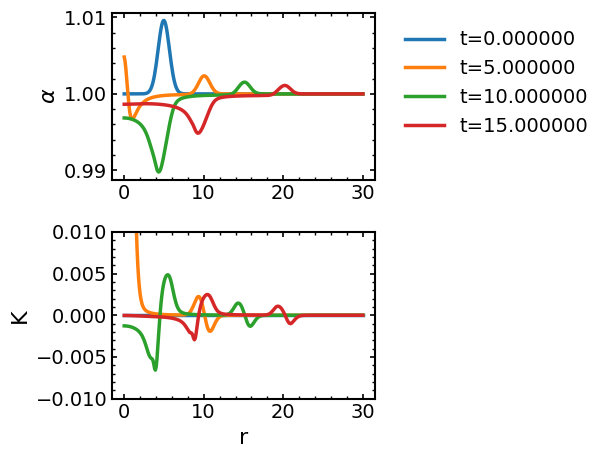

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# ==========================================
# シミュレーションの実行パート
# ==========================================

# 1. パラメータの設定
dr = 0.1
Nr = 300            # 空間グリッド数 (r = 30.0 まで)
dt = 0.25 * dr      # クーラン条件 (CFL) を満たすように時間刻みを設定
total_steps = 1500   # 総タイムステップ数
plot_interval = 200  # プロットするステップ間隔
t_final = 15.0
t_interval = 5.0
t_out = 0.0
# 2. ソルバーの初期化
# 初期パルス: 振幅 alpha0=0.01, 中心 r0=5.0
solver = BSSNSolver(Nr=Nr, dr=dr, alpha0=0.01, r0=5.0)

# プロット用の設定
plt.figure(figsize=(10, 12))
# ゴーストセルを除いた物理領域の座標
r_physical = solver.r[solver.nghost:-solver.nghost]

# 初期状態 (t=0) のラプス関数 α をプロット
PlotSnapInit()
alpha_initial = solver.u[3, solver.nghost:-solver.nghost]
K_initial = solver.v[1, solver.nghost:-solver.nghost]
time_initial = 0.0
PlotSnap(time_initial,r_physical,alpha_initial,K_initial)

# 3. 時間発展ループ
print("Simulation started...")
for step in range(1, total_steps + 1):
    current_time = step * dt

    # PIRK2スキームで1ステップ時間を進める
    solver.step_pirk2(dt)

    # 一定ステップごとにプロットに追加
    #if step % plot_interval == 0:
    if current_time  >= t_out + t_interval:
        # ラプス関数 α の値を取得 (u[3] が alpha)
        alpha_current = solver.u[3, solver.nghost:-solver.nghost]
        K_current = solver.v[0, solver.nghost:-solver.nghost]
        PlotSnap(current_time,r_physical,alpha_current,K_current)
        print(f"  Step {step}/{total_steps} (t = {current_time:.2f}) completed.")
        t_out = current_time

    if current_time > t_final:
            break
# 4. 結果の描画
PlotSnapFin()
